# Dataset Conversion

Notebook to convert OMAMA NPZ files to PNGs and build Mammo-CLIP CSV metadata. Run after activating the `mammo_clip` conda environment.


In [1]:
from pathlib import Path
import random
import shutil
import json

import numpy as np
import pandas as pd
from PIL import Image

SCRATCH_ROOT = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001")
TEST_BALANCED = SCRATCH_ROOT / "mammo-clip" / "test_balanced"
NPZ_DIR = TEST_BALANCED / "images"
METADATA_DIR = TEST_BALANCED / "metadata"
OUTPUT_ROOT = SCRATCH_ROOT / "mammo-clip" / "data" / "omama_subset"
PNG_DIR = OUTPUT_ROOT / "images_png"
CSV_PATH = OUTPUT_ROOT / "omama_subset.csv"

PNG_DIR.mkdir(parents=True, exist_ok=True)



## Sample Selection

Adjust `TOTAL_IMAGES` or `CANCER_RATIO` to control subset size and balance.


In [2]:
TOTAL_IMAGES = 100
CANCER_RATIO = 0.5  # fraction of cancer cases
random.seed(42)

# collect metadata into lists
data = []
for meta_path in METADATA_DIR.glob("*.json"):
    with meta_path.open() as f:
        meta = json.load(f)
    label = meta.get("label")
    if not label:
        continue
    npz_name = meta_path.stem + ".npz"
    npz_path = NPZ_DIR / npz_name
    if npz_path.exists():
        data.append({
            "npz_path": npz_path,
            "meta_path": meta_path,
            "label": label,
            "patient_id": meta.get("PatientID"),
            "view": meta.get("View"),
            "laterality": meta.get("ImageLaterality"),
        })

cancer = [row for row in data if row["label"].lower() == "indexcancer"]
noncancer = [row for row in data if row["label"].lower() == "noncancer"]

num_cancer = int(TOTAL_IMAGES * CANCER_RATIO)
num_noncancer = TOTAL_IMAGES - num_cancer

subset = random.sample(cancer, num_cancer) + random.sample(noncancer, num_noncancer)
random.shuffle(subset)

len(subset), len(cancer), len(noncancer)


(100, 5803, 5803)

## NPZ → PNG Conversion

Create subfolders by patient, write PNGs, and collect CSV rows.


In [3]:
records = []

for item in subset:
    npz = np.load(item["npz_path"])
    # assume array stored under key 'arr' or first array-like entry
    if "arr" in npz:
        arr = npz["arr"]
    else:
        # fallback: take first item in npz.file
        first_key = list(npz.keys())[0]
        arr = npz[first_key]

    # normalize to 0-255 uint8 for PNG
    arr = arr.astype(np.float32)
    arr -= arr.min()
    max_val = arr.max() if arr.max() > 0 else 1.0
    arr /= max_val
    arr = (arr * 255).astype(np.uint8)

    patient = item["patient_id"] or "unknown"
    patient_dir = PNG_DIR / patient
    patient_dir.mkdir(parents=True, exist_ok=True)

    image_id = item["npz_path"].stem
    png_path = patient_dir / f"{image_id}.png"

    Image.fromarray(arr).save(png_path)

    records.append({
        "patient_id": patient,
        "image_id": image_id,
        "label": item["label"],
        "png_path": png_path,
        "npz_path": item["npz_path"],
        "meta_path": item["meta_path"],
        "view": item["view"],
        "laterality": item["laterality"],
    })

len(records)


100

## Build Mammo-CLIP CSV

Create a CSV with columns expected by `train_classifier.py` (`patient_id`, `image_id`, `fold`, `cancer`, etc.).


In [4]:
df = pd.DataFrame(records)

# map labels to binary cancer column
label_map = {
    "IndexCancer": 1,
    "indexcancer": 1,
    "Cancer": 1,
    "NonCancer": 0,
    "noncancer": 0,
}
df["cancer"] = df["label"].map(label_map)

# simple fold assignment: use 0 for validation/test placeholder, 1 for train
# adjust as needed later
train_fraction = 0.8
train_count = int(len(df) * train_fraction)
df["fold"] = 0
df.loc[df.index[:train_count], "fold"] = 1

# reorder + drop helper columns
df_output = df[[
    "patient_id",
    "image_id",
    "cancer",
    "fold",
    "png_path",
    "npz_path",
    "meta_path",
    "label",
    "view",
    "laterality",
]]

df_output.to_csv(CSV_PATH, index=False)
CSV_PATH, df_output.head()


(PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/data/omama_subset/omama_subset.csv'),
      patient_id                                 image_id  cancer  fold  \
 0  DHF6HR119VFJ   69818018559071334409099332590295076108       1     1   
 1  DHKTPGGW3SL4   90656326574057617411235901550152721288       1     1   
 2  DHI7CU56S2ZE  106201419757034823593975473675235786892       1     1   
 3  DH219ONPZ7ZH   74358448943281116026742442090683873736       1     1   
 4  DH7AQZKJG5NO  138055702974992696749277485242332952755       0     1   
 
                                             png_path  \
 0  /hpcstor6/scratch01/a/a.kanamarlapudi001/mammo...   
 1  /hpcstor6/scratch01/a/a.kanamarlapudi001/mammo...   
 2  /hpcstor6/scratch01/a/a.kanamarlapudi001/mammo...   
 3  /hpcstor6/scratch01/a/a.kanamarlapudi001/mammo...   
 4  /hpcstor6/scratch01/a/a.kanamarlapudi001/mammo...   
 
                                             npz_path  \
 0  /hpcstor6/scratch01/a/a.kanamarlapudi001/

## Quality Check: NPZ vs PNG

Plot a few random samples to verify the PNG matches the original array.


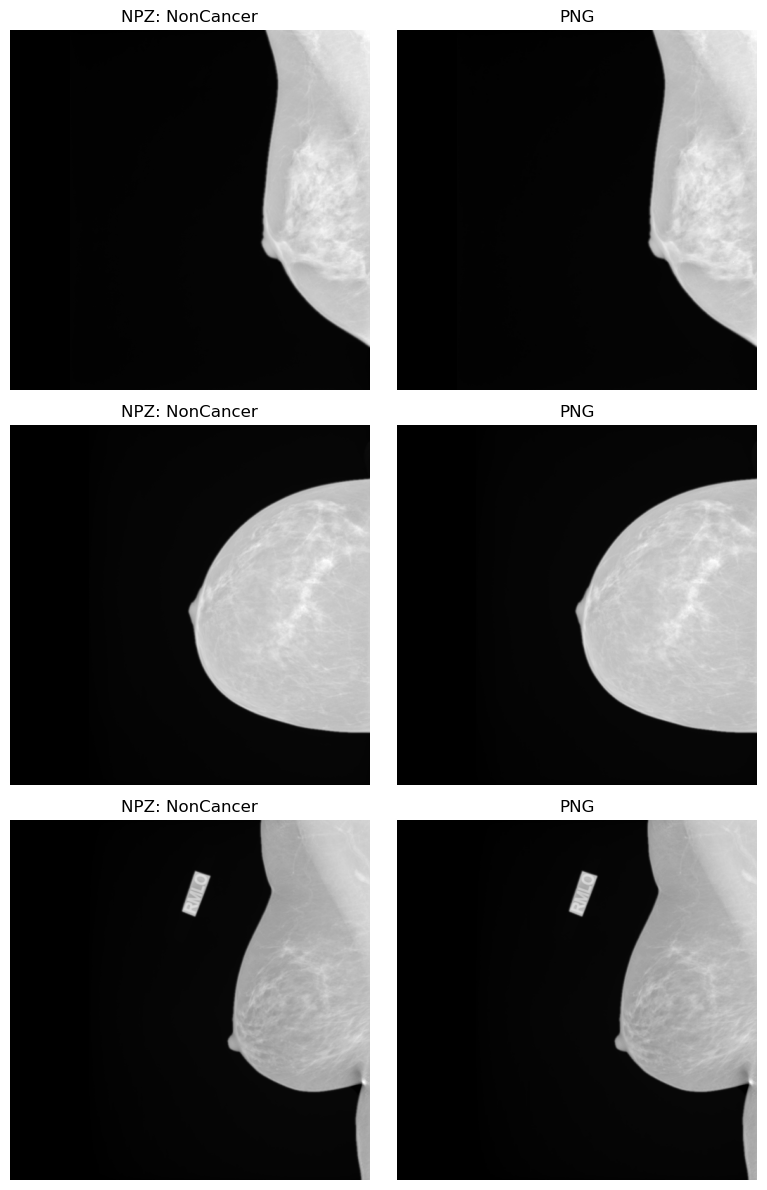

In [5]:
import matplotlib.pyplot as plt

SAMPLES_TO_SHOW = 3
sample_rows = random.sample(records, min(SAMPLES_TO_SHOW, len(records)))

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, 4 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for ax_row, item in zip(axes, sample_rows):
    npz = np.load(item["npz_path"])
    arr_npz = npz["arr"] if "arr" in npz else npz[list(npz.keys())[0]]
    arr_png = np.array(Image.open(item["png_path"]))

    ax_row[0].imshow(arr_npz, cmap="gray")
    ax_row[0].set_title(f"NPZ: {item['label']}")
    ax_row[0].axis("off")

    ax_row[1].imshow(arr_png, cmap="gray")
    ax_row[1].set_title("PNG")
    ax_row[1].axis("off")

plt.tight_layout()
plt.show()



## Summary

Check CSV, count class balance.


In [6]:
df_output["cancer"].value_counts(), len(df_output)


(cancer
 1    50
 0    50
 Name: count, dtype: int64,
 100)